# 01 — Data Pipeline Demo

Walks through fetching (or, absent a BLS API key, generating synthetic) unemployment and minimum wage data, then building the state-year analysis panel that every other notebook and the app consume.

In [ ]:
import sys
from pathlib import Path

# Walk up to the project root so the notebook runs from any working directory.
root = next(p for p in Path.cwd().resolve().parents if (p / "src").is_dir())
sys.path.insert(0, str(root))

# Data vintage: which raw inputs produced everything below. LAUS is
# revised, so an executed notebook has to carry its own provenance.
from src.data.manifest import format_manifest

print(format_manifest())


In [2]:
from src.data.loader import load_state_year_panel

panel, is_synthetic = load_state_year_panel()
print(f'is_synthetic={is_synthetic}, rows={len(panel)}, states={panel.state.nunique()}')
panel.head()

is_synthetic=False, rows=1173, states=51


,state,year,unemployment_rate,minimum_wage,federal_minimum_wage,above_federal,log_minimum_wage,adoption_year,treated,event_time
0,AK,2000,6.291667,5.65,5.15,True,1.731656,2000,True,0
1,AK,2001,6.283333,5.65,5.15,True,1.731656,2000,True,1
2,AK,2002,7.166667,5.65,5.15,True,1.731656,2000,True,2
3,AK,2003,7.675000,7.15,5.15,True,1.967112,2000,True,3
4,AK,2004,7.416667,7.15,5.15,True,1.967112,2000,True,4


If real data is available (`data/processed/panel_state_year.parquet`, built via `python -m src.data.build_panel` after setting `BLS_API_KEY` and adding a minimum wage CSV — see README), it's used automatically. Otherwise this falls back to the synthetic panel with a known ground-truth effect, so the pipeline is always runnable.

In [3]:
panel.describe()

,year,unemployment_rate,minimum_wage,federal_minimum_wage,log_minimum_wage,adoption_year,event_time
count,1173.000000,1173.000000,1173.000000,1173.000000,1173.000000,851.0,851.0
mean,2011.000000,5.454923,7.308559,6.519565,1.960869,2005.162162,5.837838
std,6.636079,2.017561,1.827847,0.957048,0.233204,4.643987,8.100517
min,2000.000000,1.925000,5.150000,5.150000,1.638997,2000.0,-21.0
25%,2005.000000,4.008333,6.150000,5.150000,1.816452,2000.0,0.0
50%,2011.000000,5.075000,7.250000,7.250000,1.981001,2006.0,6.0
75%,2017.000000,6.533333,7.930000,7.250000,2.070653,2007.0,12.0
max,2022.000000,13.675000,16.100000,7.250000,2.778819,2021.0,22.0


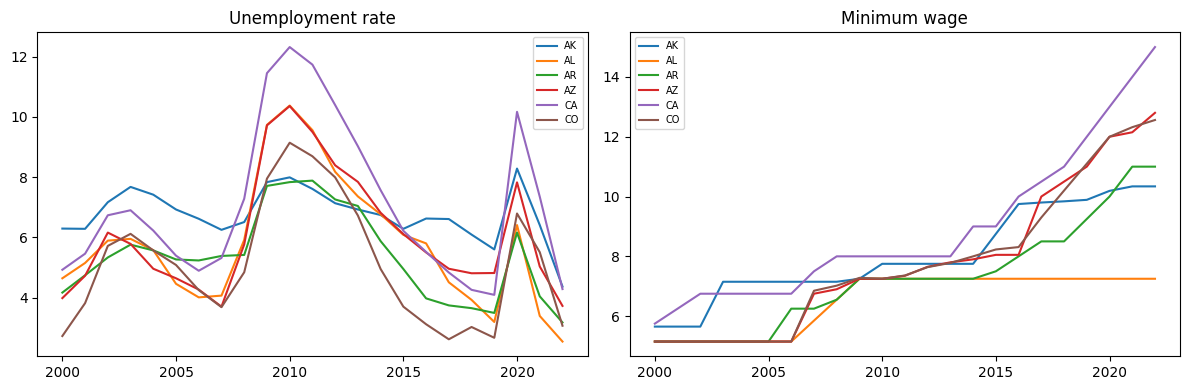

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for state in panel.state.unique()[:6]:
    sub = panel[panel.state == state]
    axes[0].plot(sub.year, sub.unemployment_rate, label=state)
    axes[1].plot(sub.year, sub.minimum_wage, label=state)
axes[0].set_title('Unemployment rate'); axes[0].legend(fontsize=7)
axes[1].set_title('Minimum wage'); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## Sanity checks

These mirror `tests/test_build_panel.py` — no duplicate state-year rows, no missing treatment values.

In [5]:
assert not panel.duplicated(subset=['state', 'year']).any()
assert not panel['minimum_wage'].isna().any()
print('Panel passes sanity checks.')

Panel passes sanity checks.
